In [102]:
from sklearn.datasets import make_classification
import numpy as np
x, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

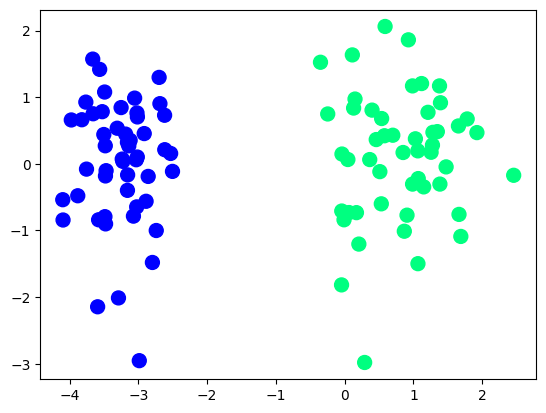

In [103]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [104]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(penalty = None ,solver="sag")
lr.fit(x,y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [105]:
print(lr.intercept_)
print(lr.coef_)

[5.77469924]
[[4.80120514 0.21187349]]


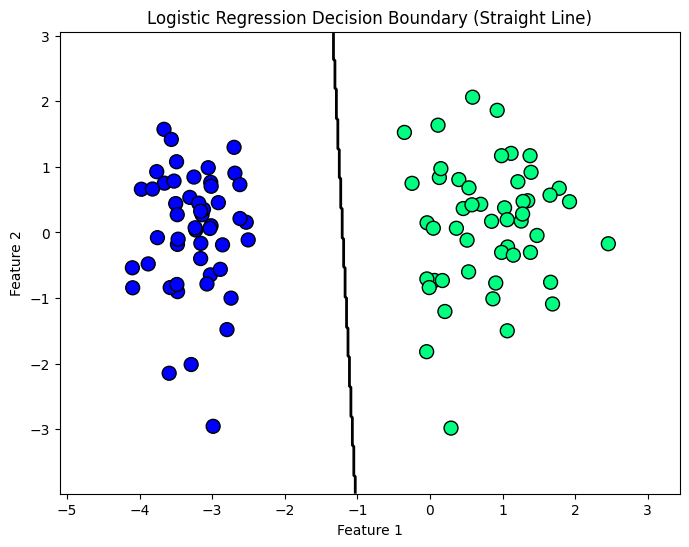

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# Plotting the decision boundary
x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='winter', s=100, edgecolors='k')
plt.title('Logistic Regression Decision Boundary (Straight Line)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [107]:
def gd(x,y):

  x = np.insert(x,0,1,axis=1)
  w = np.ones(x.shape[1])
  lr = 0.5

  for i in range(1500):
    y_hat = sigmoid(np.dot(x,w))
    w = w + lr*(np.dot((y-y_hat),x)/x.shape[0])

  print(w[0])
  print(w[1:])

In [108]:
def sigmoid(z):
  return 1/(1+np.exp(-z))


In [109]:
gd(x,y)

4.653509659397304
[4.02638833 0.14634709]


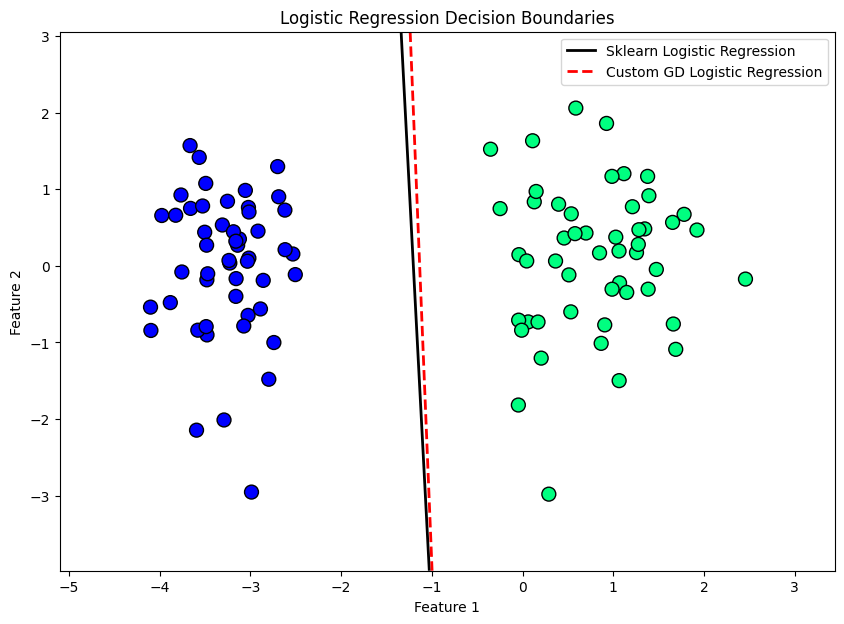

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Re-create meshgrid for decision boundary plotting (assuming x,y,lr are in scope)
x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

plt.figure(figsize=(10, 7))

# Plot the scatter points
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='winter', s=100, edgecolors='k')

# --- Plotting Scikit-learn Logistic Regression decision boundary ---
# The decision boundary is where the decision_function output is 0
Z_lr_decision = lr.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contour(xx, yy, Z_lr_decision, levels=[0], colors='black', linewidths=2, linestyles='-')

# --- Plotting Custom GD function decision boundary ---
# Extract weights from the custom GD function's output (from cell cjCWDD-WxFVt)
# These values were printed by gd(x,y)
b_gd = 4.2684411151958175   # Intercept (w[0])
w1_gd = 3.76718284        # Coefficient for x[:,0] (w[1])
w2_gd = 0.12934682        # Coefficient for x[:,1] (w[2])

# Calculate the linear combination for the custom GD model
# The decision boundary is where this linear combination is zero.
linear_combination_gd = b_gd + w1_gd * xx + w2_gd * yy
plt.contour(xx, yy, linear_combination_gd, levels=[0], colors='red', linewidths=2, linestyles='--')

plt.title('Logistic Regression Decision Boundaries')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Create custom legend handles
custom_lines = [Line2D([0], [0], color='black', lw=2, linestyle='-'),
                Line2D([0], [0], color='red', lw=2, linestyle='--')]
plt.legend(custom_lines, ['Sklearn Logistic Regression', 'Custom GD Logistic Regression'])

plt.show()